In [ ]:
devices = tf.config.list_physical_devices()
print("TensorFlow is using:", devices)


TensorFlow is using: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [1]:
import os, zipfile, random, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from collections import Counter

In [ ]:
import zipfile, shutil, os
from pathlib import Path

# Define paths
DATA_ROOT = Path("./data_extracted_fixed")
TRAIN_ZIP = r"/content/train-20251031T054123Z-1-001.zip"
VALID_ZIP = r"/content/valid-20251031T054127Z-1-001.zip"
TEST_ZIP  = r"/content/test-20251031T054122Z-1-001.zip"

# Clean old extraction if exists
if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

def smart_extract(zip_path, target_dir):
    """Extract zip and automatically detect the actual 'train/valid/test' folder level."""
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print(f"Extracted to {target_dir}")

    # Find the real dataset folder (contains class subfolders)
    # e.g., /data/train/train/...  or /data/train/...
    candidates = list(Path(target_dir).rglob("train"))
    if not candidates:
        candidates = list(Path(target_dir).rglob("Train"))
    if candidates:
        print(f"Found train folder candidate: {candidates[0]}")
    return target_dir

# Extract all datasets
smart_extract(TRAIN_ZIP, DATA_ROOT / "train")
smart_extract(VALID_ZIP, DATA_ROOT / "valid")
smart_extract(TEST_ZIP,  DATA_ROOT / "test")

# Detect the deepest actual directories that contain class folders
def find_actual_dataset_dir(base_dir):
    base_dir = Path(base_dir)
    subdirs = [p for p in base_dir.rglob("*") if p.is_dir() and any(f.suffix.lower() in ['.jpg', '.jpeg', '.png'] for f in p.glob("*"))]
    if subdirs:
        # Return parent folder containing class folders
        parents = {p.parent for p in subdirs}
        best = min(parents, key=lambda p: len(p.parts))
        print(f"✅ Found valid dataset directory: {best}")
        return best
    else:
        print(f"⚠️ No images found under {base_dir}, check your zip structure.")
        return base_dir

TRAIN_DIR = find_actual_dataset_dir(DATA_ROOT / "train")
VALID_DIR = find_actual_dataset_dir(DATA_ROOT / "valid")
TEST_DIR  = find_actual_dataset_dir(DATA_ROOT / "test")

print(f"\nFinal dataset directories:")
print(f"Train dir: {TRAIN_DIR}")
print(f"Valid dir: {VALID_DIR}")
print(f"Test dir:  {TEST_DIR}")

# Quick verification
for root, dirs, files in os.walk(TRAIN_DIR):
    print(f"\nSample structure check:\n{root} -> {len(dirs)} class folders")
    print("Classes:", dirs)
    break

Extracting /content/train-20251031T054123Z-1-001.zip ...
Extracted to data_extracted_fixed/train
Found train folder candidate: data_extracted_fixed/train/train
Extracting /content/valid-20251031T054127Z-1-001.zip ...
Extracted to data_extracted_fixed/valid
Extracting /content/test-20251031T054122Z-1-001.zip ...
Extracted to data_extracted_fixed/test
✅ Found valid dataset directory: data_extracted_fixed/train/train
✅ Found valid dataset directory: data_extracted_fixed/valid/valid
✅ Found valid dataset directory: data_extracted_fixed/test/test

Final dataset directories:
Train dir: data_extracted_fixed/train/train
Valid dir: data_extracted_fixed/valid/valid
Test dir:  data_extracted_fixed/test/test

Sample structure check:
data_extracted_fixed/train/train -> 4 class folders
Classes: ['meningioma', 'pituitary', 'glioma', 'no_tumor']


In [ ]:
# 1) CONFIG

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_ROOT = Path("data_extracted_fixed")   # already extracted (from your previous step)
TRAIN_DIR = DATA_ROOT / "train" / "train"
VALID_DIR = DATA_ROOT / "valid" / "valid"
TEST_DIR  = DATA_ROOT / "test" / "test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
OUTPUT_DIR = Path("models_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [ ]:
# 2️) DATA PREPROCESSING (Fixed for RGB inputs)

print("✅ Preparing datasets...")

def create_dataset(directory, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        batch_size=batch_size,
        image_size=img_size,
        shuffle=shuffle,
        seed=SEED,
        color_mode="rgb"   # 👈 Force 3-channel RGB to avoid grayscale mismatch
    )
    return ds

train_ds = create_dataset(TRAIN_DIR)
val_ds   = create_dataset(VALID_DIR, shuffle=False)
test_ds  = create_dataset(TEST_DIR, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ✅ Sanity check: verify image shape
for images, labels in train_ds.take(1):
    print(f"Sample image batch shape: {images.shape}")
    print(f"Sample label batch shape: {labels.shape}")

# Normalize pixel values to [0–1]
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for better performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

✅ Preparing datasets...
Found 1695 files belonging to 4 classes.
Found 502 files belonging to 4 classes.
Found 246 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Sample image batch shape: (32, 224, 224, 3)
Sample label batch shape: (32,)


In [ ]:
# 3️⃣ DATA AUGMENTATION
# --------------------------------------------
# Augmenting the training images to improve model generalization.
# This helps the model learn to recognize fish under varied conditions
# like different orientations, zooms, and lighting.
# --------------------------------------------

print("✅ Setting up augmentation...")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),  # Flips images both horizontally and vertically
    layers.RandomRotation(0.2),                    # Randomly rotates images up to 20%
    layers.RandomZoom(0.15),                       # Randomly zooms in/out by 15%
    layers.RandomTranslation(0.1, 0.1),            # Shifts images horizontally & vertically by 10%
    layers.RandomContrast(0.1)                     # Adjusts image contrast by ±10%
], name="data_augmentation")


✅ Setting up augmentation...


In [ ]:
# 4️⃣ MODEL BUILDING (Fixed & Verified)
# --------------------------------------------------------
# In this section, we build two types of models:
#   (1) A Custom CNN (built from scratch)
#   (2) Transfer Learning Models using pre-trained architectures
# --------------------------------------------------------

print("✅ Building models...")

# ---- (1) Custom CNN Model ----
# Purpose: Build a CNN from scratch for classification.
# It uses multiple convolutional layers, batch normalization, and dropout for regularization.

def build_custom_cnn(input_shape=(224,224,3), num_classes=4):
    model = models.Sequential([
        data_augmentation,                                  # Applies transformations (flip, rotate, zoom, etc.) to prevent overfitting.
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(), #Normalizes activations, stabilizing and speeding up training.
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),     #Reduces image size, keeping only important features.

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),    #Learns local features (edges, shapes). Increasing filters (32 → 64 → 128) captures more detail.
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),     #Learns high-level patterns (fully connected).
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')      # Output layer for multi-class classification
    ])
    return model

# Compile custom CNN
custom_cnn = build_custom_cnn((224,224,3), num_classes)
custom_cnn.compile(optimizer='adam', #adaptive gradient method (efficient and common)
                   loss='sparse_categorical_crossentropy', #used when class labels are integers
                   metrics=['accuracy']) #monitor accuracy during training
custom_cnn.summary()


# ---- (2) Transfer Learning Models ----
# Purpose: Use pre-trained models (ResNet50, MobileNetV2, InceptionV3)
# with ImageNet weights for feature extraction and classification.
def build_transfer_model(base_model, num_classes=4):
    base_model.trainable = False                                # Freeze base layers to retain learned features
    inputs = layers.Input(shape=(224,224,3))
    x = data_augmentation(inputs)                               # Apply data augmentation
    x = base_model(x, training=False)                           # Pass data through base model
    x = layers.GlobalAveragePooling2D()(x)                      # Convert feature maps to feature vector
    x = layers.Dropout(0.3)(x)                                  # Regularization
    outputs = layers.Dense(num_classes, activation='softmax')(x) # Classification layer
    model = models.Model(inputs, outputs)
    return model

# Build models for comparison
transfer_models = {
    "ResNet50": build_transfer_model(applications.ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3)), num_classes),
    "MobileNetV2": build_transfer_model(applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3)), num_classes),
    "InceptionV3": build_transfer_model(applications.InceptionV3(weights="imagenet", include_top=False, input_shape=(224,224,3)), num_classes),
}


✅ Building models...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


✅ Training models...

Training CustomCNN ...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3615 - loss: 1.8953

53/53 ━━━━━━━━━━━━━━━━━━━━ 195s 4s/step - accuracy: 0.3632 - loss: 1.8885 - val_accuracy: 0.2470 - val_loss: 1.3719
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.5600 - loss: 1.2635 - val_accuracy: 0.2351 - val_loss: 1.3727
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.5853 - loss: 1.1799 - val_accuracy: 0.5219 - val_loss: 1.4001
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 192s 4s/step - accuracy: 0.5938 - loss: 1.1572 - val_accuracy: 0.5080 - val_loss: 1.4967
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.6288 - loss: 1.0455 - val_accuracy: 0.4502 - val_loss: 1.5999


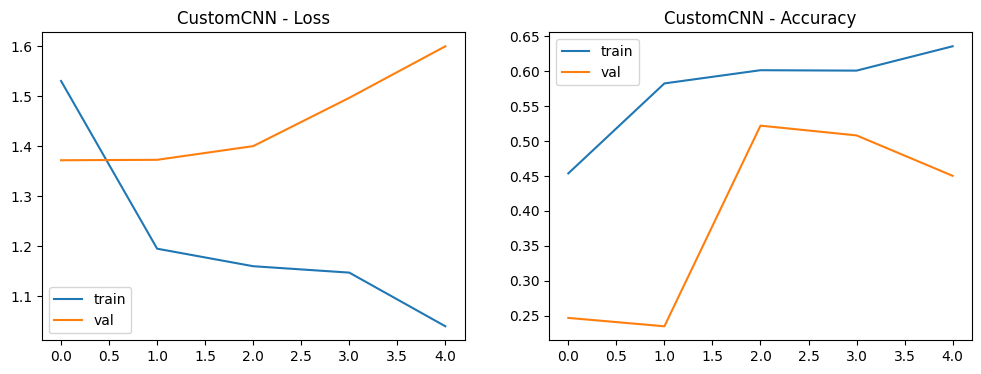


Training ResNet50 ...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2221 - loss: 1.9794

53/53 ━━━━━━━━━━━━━━━━━━━━ 259s 5s/step - accuracy: 0.2221 - loss: 1.9770 - val_accuracy: 0.2470 - val_loss: 1.4373
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2620 - loss: 1.5298

53/53 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.2621 - loss: 1.5293 - val_accuracy: 0.3386 - val_loss: 1.3530
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2728 - loss: 1.4721

53/53 ━━━━━━━━━━━━━━━━━━━━ 250s 5s/step - accuracy: 0.2729 - loss: 1.4719 - val_accuracy: 0.3446 - val_loss: 1.3431
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2846 - loss: 1.4627

53/53 ━━━━━━━━━━━━━━━━━━━━ 265s 5s/step - accuracy: 0.2848 - loss: 1.4624 - val_accuracy: 0.3586 - val_loss: 1.3329
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2798 - loss: 1.4391

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 249s 5s/step - accuracy: 0.3298 - loss: 1.3808 - val_accuracy: 0.4243 - val_loss: 1.2712
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3488 - loss: 1.3583

53/53 ━━━━━━━━━━━━━━━━━━━━ 249s 5s/step - accuracy: 0.3488 - loss: 1.3580 - val_accuracy: 0.4223 - val_loss: 1.2640
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3591 - loss: 1.3578

53/53 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.3591 - loss: 1.3576 - val_accuracy: 0.4283 - val_loss: 1.2560
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3515 - loss: 1.3261

53/53 ━━━━━━━━━━━━━━━━━━━━ 251s 5s/step - accuracy: 0.3515 - loss: 1.3263 - val_accuracy: 0.4283 - val_loss: 1.2503
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3936 - loss: 1.2983

53/53 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.3935 - loss: 1.2984 - val_accuracy: 0.4303 - val_loss: 1.2417


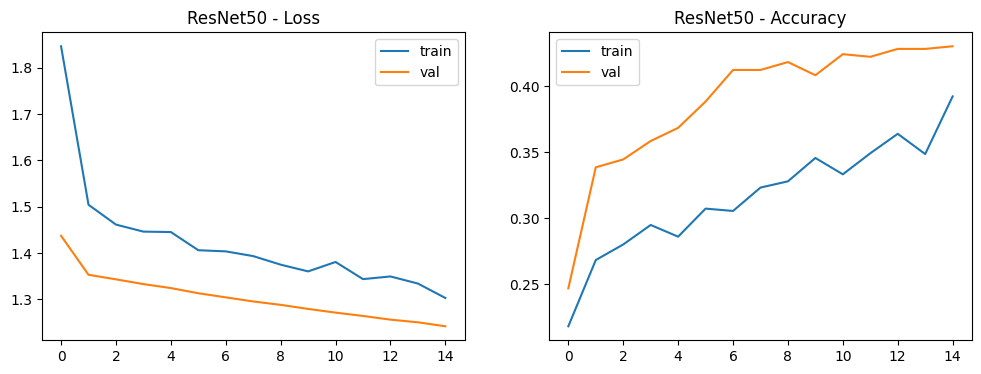


Training MobileNetV2 ...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.3083 - loss: 1.4836

53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3093 - loss: 1.4821 - val_accuracy: 0.4841 - val_loss: 1.2045
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.4719 - loss: 1.2388

53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4723 - loss: 1.2380 - val_accuracy: 0.5697 - val_loss: 1.0659
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.5471 - loss: 1.1006

53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5474 - loss: 1.0999 - val_accuracy: 0.5916 - val_loss: 0.9978
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 996ms/step - accuracy: 0.6093 - loss: 0.9694

53/53 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6096 - loss: 0.9688 - val_accuracy: 0.6275 - val_loss: 0.9117
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.6537 - loss: 0.8912

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7086 - loss: 0.7191 - val_accuracy: 0.6873 - val_loss: 0.7623
Epoch 11/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - accuracy: 0.7446 - loss: 0.6820

53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7446 - loss: 0.6817 - val_accuracy: 0.6972 - val_loss: 0.7319
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.7384 - loss: 0.6596

53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7385 - loss: 0.6595 - val_accuracy: 0.7032 - val_loss: 0.7211
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.7630 - loss: 0.6305

53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7628 - loss: 0.6306 - val_accuracy: 0.6992 - val_loss: 0.7161
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7700 - loss: 0.6377 - val_accuracy: 0.6932 - val_loss: 0.7353
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7490 - loss: 0.6486   

53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7491 - loss: 0.6480 - val_accuracy: 0.7072 - val_loss: 0.7093


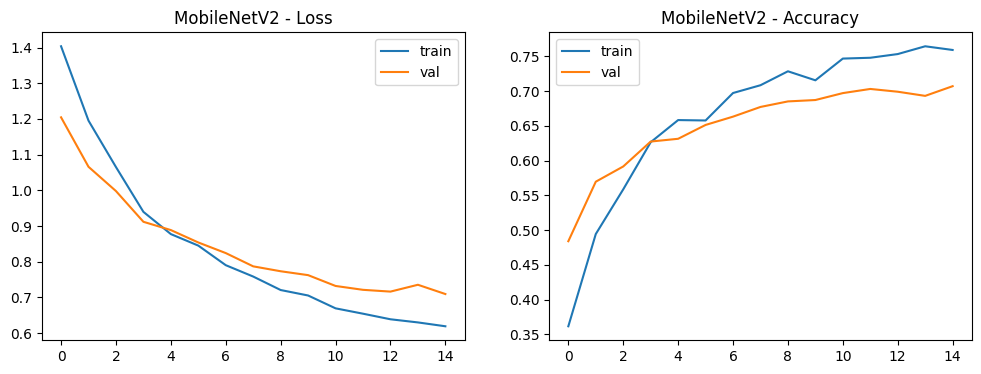


Training InceptionV3 ...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2499 - loss: 1.6728

53/53 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.2511 - loss: 1.6702 - val_accuracy: 0.3944 - val_loss: 1.3363
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4402 - loss: 1.2966

53/53 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.4406 - loss: 1.2959 - val_accuracy: 0.5199 - val_loss: 1.1448
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5083 - loss: 1.1532

53/53 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.5086 - loss: 1.1524 - val_accuracy: 0.5657 - val_loss: 1.0290
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5799 - loss: 1.0228

53/53 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.5799 - loss: 1.0229 - val_accuracy: 0.6116 - val_loss: 0.9454
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6288 - loss: 0.9475

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.7172 - loss: 0.7498 - val_accuracy: 0.7052 - val_loss: 0.7411
Epoch 11/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7213 - loss: 0.7287

53/53 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.7213 - loss: 0.7286 - val_accuracy: 0.6972 - val_loss: 0.7351
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7342 - loss: 0.7162

53/53 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.7340 - loss: 0.7162 - val_accuracy: 0.7131 - val_loss: 0.7036
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7272 - loss: 0.6962

53/53 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.7273 - loss: 0.6962 - val_accuracy: 0.7131 - val_loss: 0.7004
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.7341 - loss: 0.6890 - val_accuracy: 0.7052 - val_loss: 0.7084
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7576 - loss: 0.6200

53/53 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.7572 - loss: 0.6210 - val_accuracy: 0.7490 - val_loss: 0.6617


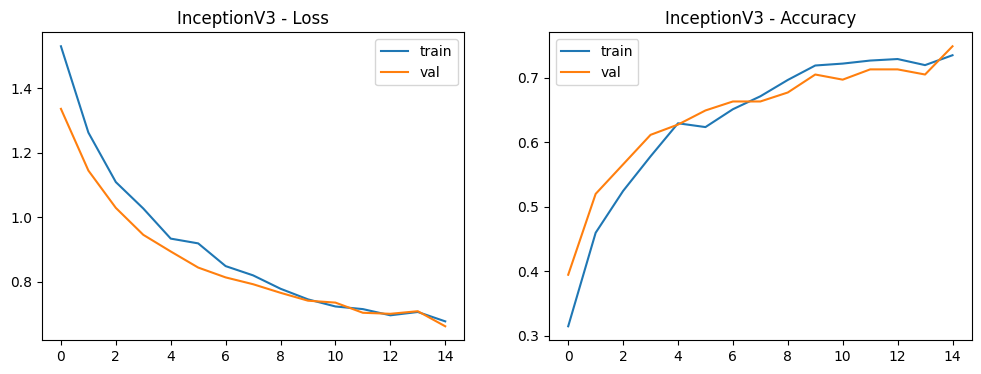

In [ ]:
# 5️) MODEL TRAINING

print("✅ Training models...")
results = []

def train_model(model, name):
    print(f"\nTraining {name} ...")
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{OUTPUT_DIR}/{name}_best.h5", save_best_only=True)
    ]
    model.compile(optimizer=optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb)
    # Plot history
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{name} - Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{name} - Accuracy'); plt.legend()
    plt.show()
    return model, history

# Train Custom CNN
custom_cnn, history_cnn = train_model(custom_cnn, "CustomCNN")

# Train Transfer Models
for name, model in transfer_models.items():
    model, hist = train_model(model, name)
    transfer_models[name] = model

✅ Evaluating models...

📊 CustomCNN Results:
Accuracy=0.2480  Precision=0.1451  Recall=0.2480  F1=0.1319
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00        80
  meningioma       0.36      0.13      0.19        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.24      0.98      0.38        54

    accuracy                           0.25       246
   macro avg       0.15      0.28      0.14       246
weighted avg       0.15      0.25      0.13       246



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

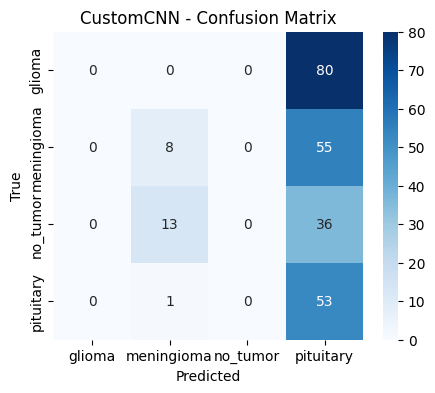


📊 ResNet50 Results:
Accuracy=0.4431  Precision=0.5702  Recall=0.4431  F1=0.3257
              precision    recall  f1-score   support

      glioma       0.39      1.00      0.57        80
  meningioma       1.00      0.02      0.03        63
    no_tumor       0.75      0.55      0.64        49
   pituitary       0.17      0.02      0.03        54

    accuracy                           0.44       246
   macro avg       0.58      0.40      0.32       246
weighted avg       0.57      0.44      0.33       246



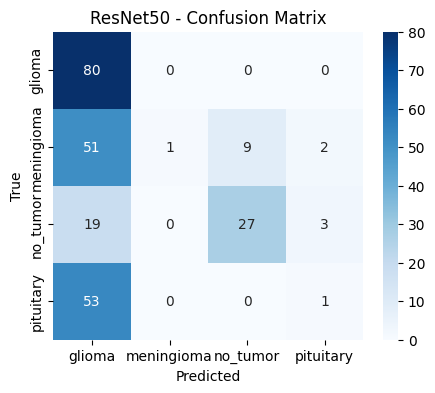


📊 MobileNetV2 Results:
Accuracy=0.6829  Precision=0.7328  Recall=0.6829  F1=0.6722
              precision    recall  f1-score   support

      glioma       0.86      0.74      0.79        80
  meningioma       0.65      0.32      0.43        63
    no_tumor       0.90      0.71      0.80        49
   pituitary       0.50      1.00      0.67        54

    accuracy                           0.68       246
   macro avg       0.73      0.69      0.67       246
weighted avg       0.73      0.68      0.67       246



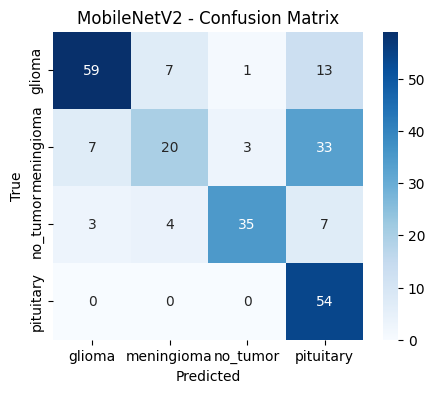


📊 InceptionV3 Results:
Accuracy=0.7033  Precision=0.7194  Recall=0.7033  F1=0.6967
              precision    recall  f1-score   support

      glioma       0.75      0.81      0.78        80
  meningioma       0.63      0.46      0.53        63
    no_tumor       0.91      0.63      0.75        49
   pituitary       0.61      0.89      0.72        54

    accuracy                           0.70       246
   macro avg       0.72      0.70      0.69       246
weighted avg       0.72      0.70      0.70       246



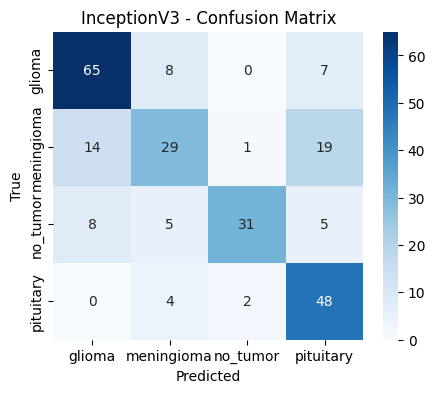

In [ ]:
# 6️⃣ MODEL EVALUATION
# --------------------------------------------------------
# Purpose: Evaluate each model's performance using the test dataset.
# Metrics used:
#   - Accuracy
#   - Precision
#   - Recall
#   - F1-Score
#   - Confusion Matrix visualization
# --------------------------------------------------------

print("✅ Evaluating models...")

# 🔹 Define Evaluation Function
def evaluate_model(model, name):
    """
    Evaluates a trained model on the test dataset and prints performance metrics.
    """
    y_true, y_pred = [], []   # Lists to store true and predicted labels

    # Iterate over batches in test dataset
    for imgs, labels in test_ds:
        preds = model.predict(imgs, verbose=0)         # Predict probabilities
        y_true.extend(labels.numpy())                  # True labels
        y_pred.extend(np.argmax(preds, axis=1))        # Convert softmax outputs to class indices

    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    # Print summary
    print(f"\n📊 {name} Results:")
    print(f"Accuracy = {acc:.4f}  Precision = {prec:.4f}  Recall = {rec:.4f}  F1-Score = {f1:.4f}")

    # Generate detailed classification report
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Return performance summary for comparison
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


# 🔹 Evaluate All Models (Custom CNN + Transfer Learning)
results = []  # Store results for comparison
results.append(evaluate_model(custom_cnn, "CustomCNN"))

# Evaluate each transfer learning model
for name, model in transfer_models.items():
    results.append(evaluate_model(model, name))



✅ Model Comparison Summary:
         model  accuracy  precision    recall        f1
3  InceptionV3  0.703252   0.719407  0.703252  0.696660
2  MobileNetV2  0.682927   0.732836  0.682927  0.672216
1     ResNet50  0.443089   0.570232  0.443089  0.325723
0    CustomCNN  0.247967   0.145065  0.247967  0.131905


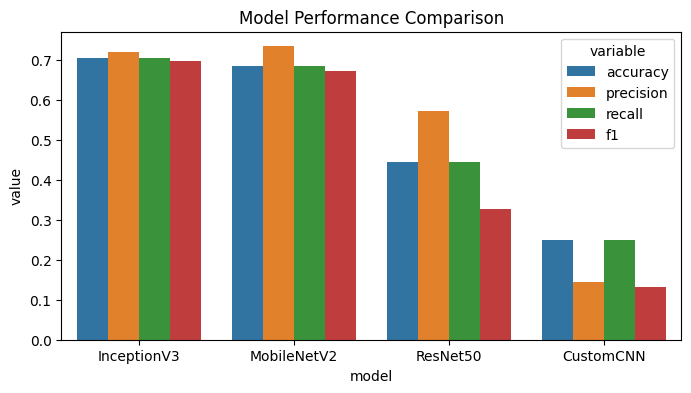


🏆 Best Performing Model: InceptionV3


In [ ]:
# 7️) MODEL COMPARISON

df = pd.DataFrame(results).sort_values("f1", ascending=False)
print("\n✅ Model Comparison Summary:")
print(df)

plt.figure(figsize=(8,4))
sns.barplot(data=df.melt(id_vars='model', value_vars=['accuracy','precision','recall','f1']),
            x='model', y='value', hue='variable')
plt.title("Model Performance Comparison")
plt.show()

best_model_name = df.iloc[0]["model"]
print(f"\n🏆 Best Performing Model: {best_model_name}")

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# save to h5
best_model_path = f"models_outputs/{best_model_name}_best.h5"
best_model = load_model(best_model_path)

# Save to pickle
pickle_path = f"models_outputs/{best_model_name}_best.pkl"
with open(pickle_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"✅ Saved best model as: {pickle_path}")

✅ Saved best model as: models_outputs/InceptionV3_best.pkl


✅ Model loaded successfully!


Saving Tr-no_0016_jpg.rf.cdf780eb3e921d6fb86ff2ee6b00c800.jpg to Tr-no_0016_jpg.rf.cdf780eb3e921d6fb86ff2ee6b00c800.jpg


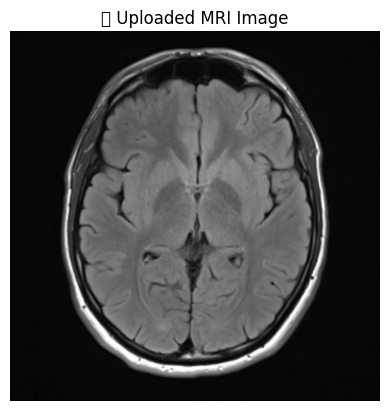

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🎯 Prediction Results
Predicted Tumor Type: no_tumor
Confidence: 76.11%

glioma       : 10.92%
meningioma   : 7.94%
no_tumor     : 76.11%
pituitary    : 5.03%


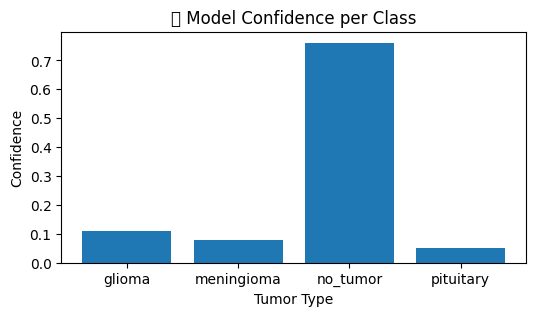

In [ ]:
# 🧠 Brain Tumor MRI Prediction Demo (Colab Cell)

import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pickle
from google.colab import files

# -------------------------------------------------
# 🔧 CONFIGURATION
MODEL_PATH = "/content/models_outputs/InceptionV3_best.pkl"  # update if needed
IMG_SIZE = (224, 224)
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
# -------------------------------------------------

# 🧩 Load Trained Model
with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

print("✅ Model loaded successfully!")

# 📤 Upload an image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# 🖼️ Load and display image
image = Image.open(img_path).convert("RGB")
plt.imshow(image)
plt.axis('off')
plt.title("🩺 Uploaded MRI Image")
plt.show()

# 🔄 Preprocess image
img_array = np.array(image)
img_resized = tf.image.resize(img_array, IMG_SIZE)
img_normalized = img_resized / 255.0
img_expanded = np.expand_dims(img_normalized, axis=0)

# 🔍 Predict tumor type
preds = model.predict(img_expanded)
pred_class = np.argmax(preds, axis=1)[0]
pred_label = CLASS_NAMES[pred_class]
confidence = preds[0][pred_class]

# 🧾 Display results
print("\n🎯 Prediction Results")
print(f"Predicted Tumor Type: {pred_label}")
print(f"Confidence: {confidence*100:.2f}%\n")

# 📊 Show confidence for all classes
for i, c in enumerate(CLASS_NAMES):
    print(f"{c:12s} : {preds[0][i]*100:.2f}%")

plt.figure(figsize=(6,3))
plt.bar(CLASS_NAMES, preds[0])
plt.title("🔍 Model Confidence per Class")
plt.xlabel("Tumor Type")
plt.ylabel("Confidence")
plt.show()
